In [2]:
# Import packages
from pathlib import Path

PROJECT_DIR = Path("/home/mcaskey/10XvParse/")
ANALYSIS_NAME = "Analysis_5"
INDEX_DIR = PROJECT_DIR / "Index" / "human"
ANALYSIS_DIR = Path.cwd()
LOGCPM_TRANSFORM = True
CUTOFFS = [75, 300, 300, 300]
FULL_GENE_INFO_PATH = Path("gene_data/gene_comparisons.csv")

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import scrublet as scr
import pandas as pd
import anndata as ad
import scanpy as sc

from XvP_utils import plotting

In [4]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [5]:
# # In case you change the package
# import importlib
# importlib.reload(plotting)

In [6]:
data_10x = plotting.init_processing(analysis_name=ANALYSIS_NAME, project_dir=PROJECT_DIR, data_name='10x', assay ="10x", data_title='10X Genomics')
data_polyT = plotting.init_processing(analysis_name=ANALYSIS_NAME, project_dir=PROJECT_DIR, data_name='polyT', assay="parse", data_title="Parse 3'")
data_randO = plotting.init_processing(analysis_name=ANALYSIS_NAME, project_dir=PROJECT_DIR, data_name='randO', assay="parse", data_title='Parse Random Oligo')
data_parse = plotting.init_processing(analysis_name=ANALYSIS_NAME, project_dir=PROJECT_DIR, data_name='parse', assay="parse", data_title='Parse', modified=True)

raw_datasets = [data_10x, data_polyT, data_randO, data_parse]

# Population Upsampling Estimation

PreSeq output already exists for all datasets.


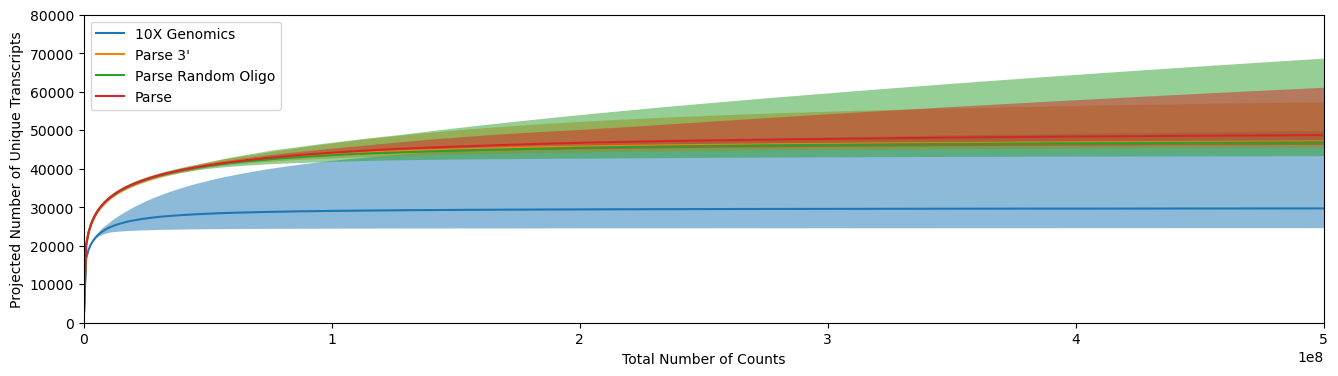

In [7]:
# Launches PreSeq in the background — does not block the notebook.
# Rerun plot_upsample() in a later cell once jobs complete.
plotting.upsample(raw_datasets, Path("preseq"), overwrite=False)
plotting.plot_upsample(raw_datasets, Path("preseq"), xlim=5e8, ylim=8e4)

# Quality Control Comparison

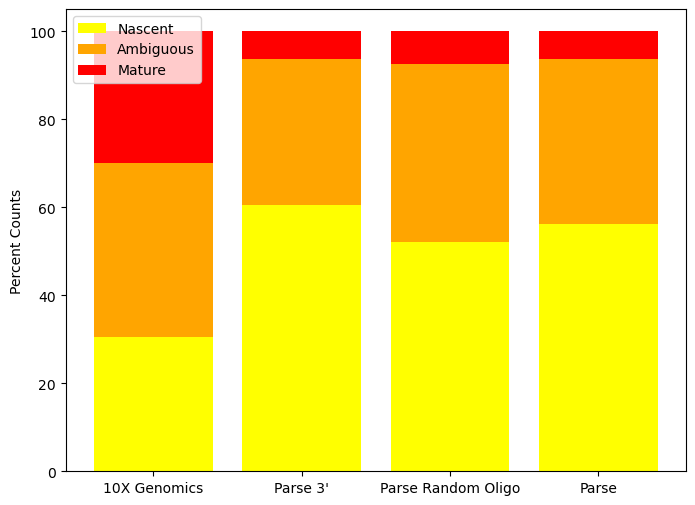

In [8]:
plotting.plot_nascent_mature_ratios(raw_datasets)

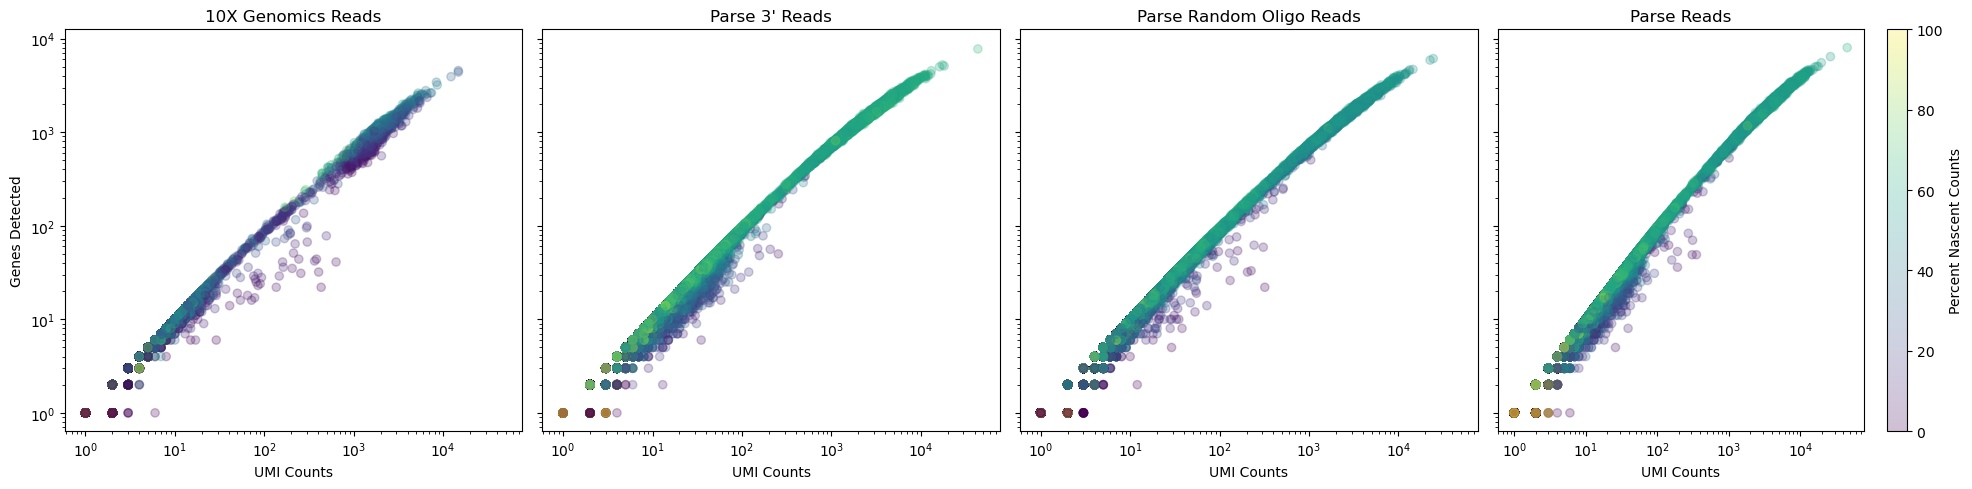

In [9]:
plotting.scatter_reads(raw_datasets)

In [10]:
# Path to save gene metadata so don't need to query Ensembl
# more than once
gene_info = plotting.query_ensembl(ANALYSIS_DIR, index_dir=INDEX_DIR, overwrite=True)

In [11]:
for data in raw_datasets:
    plotting.add_cell_metrics(data, gene_info)

/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.


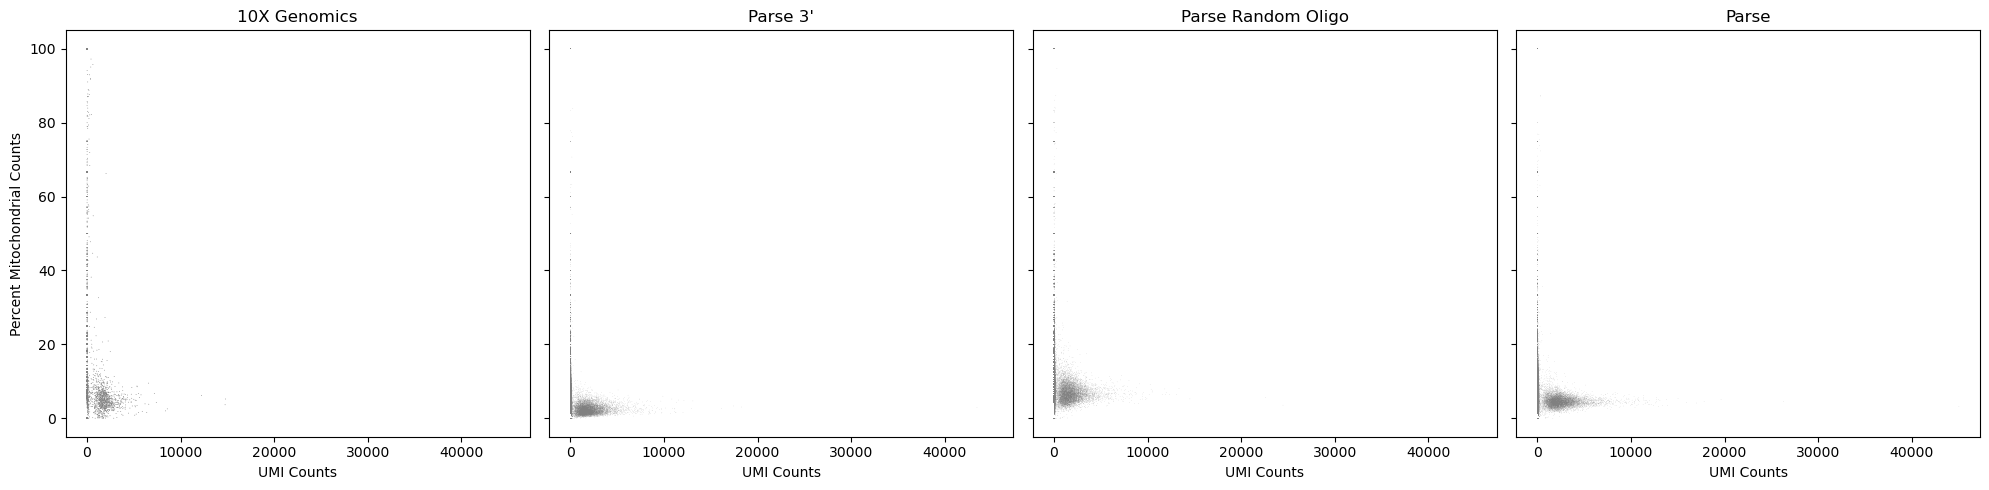

In [12]:
plotting.mito_scatter(raw_datasets)

1,190 cells passed the 75 UMI threshold for 10X Genomics
Applied CPM normalization and log1p transformation to the filtered data.
8,148 cells passed the 300 UMI threshold for Parse 3'
Applied CPM normalization and log1p transformation to the filtered data.
8,103 cells passed the 300 UMI threshold for Parse Random Oligo
Applied CPM normalization and log1p transformation to the filtered data.
8,202 cells passed the 300 UMI threshold for Parse
Applied CPM normalization and log1p transformation to the filtered data.


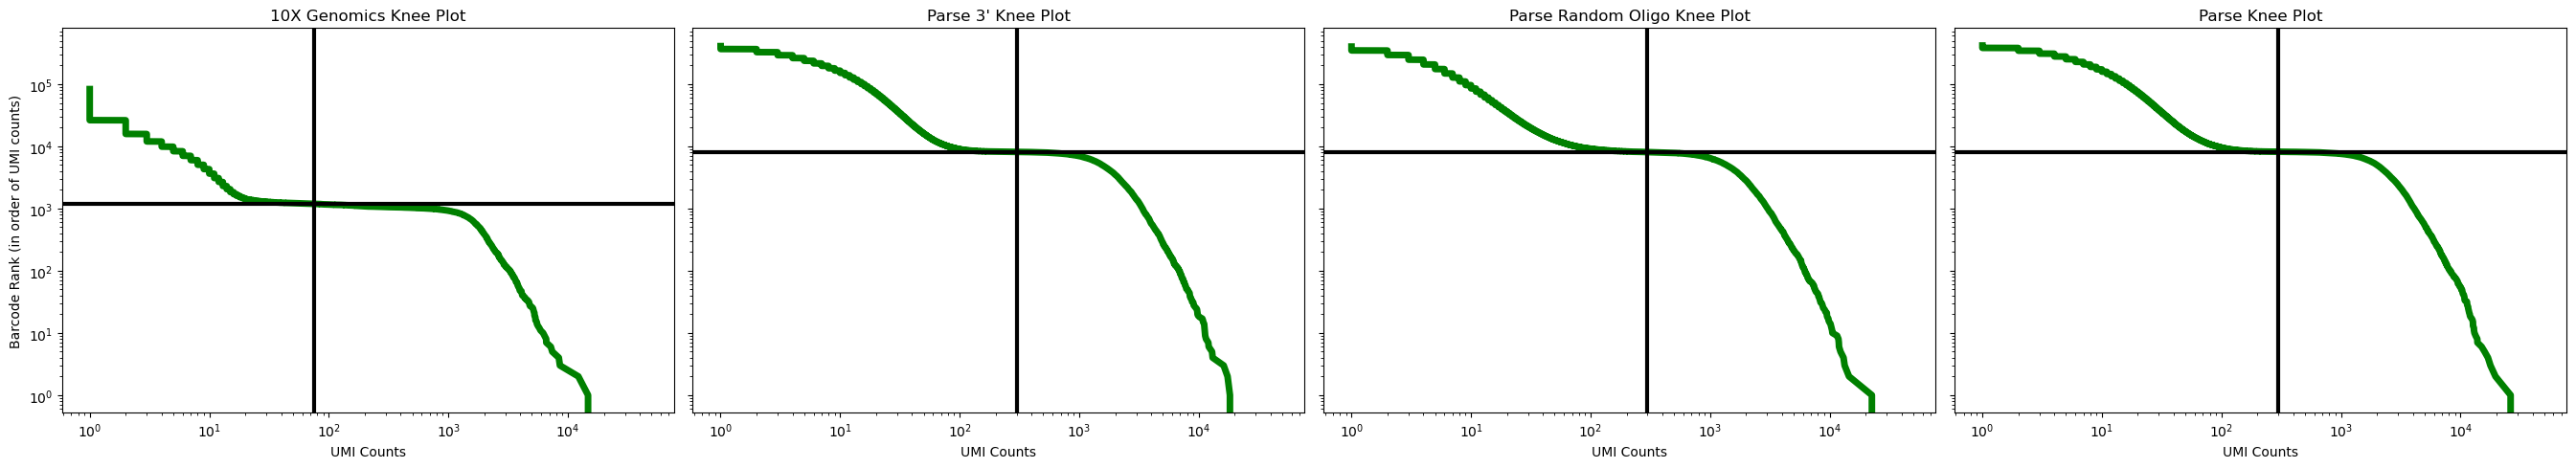

In [13]:
datasets = plotting.knee_plot(raw_datasets, cutoffs=CUTOFFS, transform=LOGCPM_TRANSFORM)

In [14]:
gene_info = plotting.update_gene_info(gene_info, datasets, FULL_GENE_INFO_PATH)

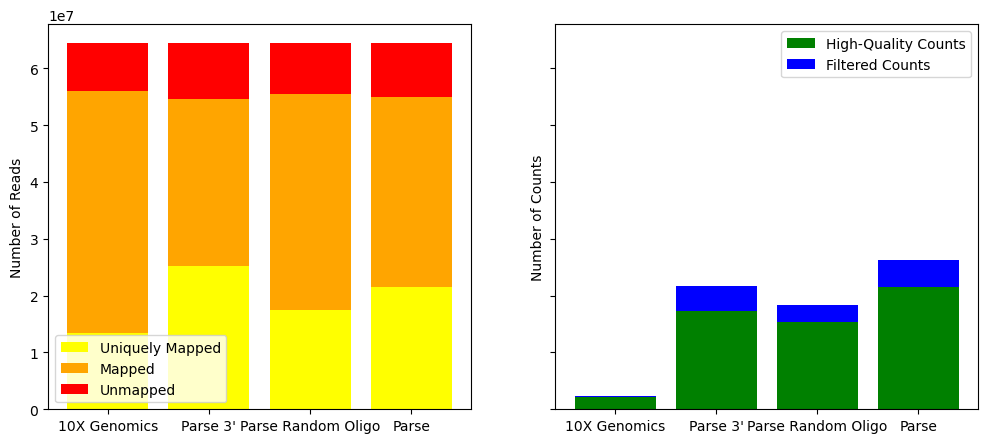

In [15]:
plotting.plot_filtering_metrics(datasets)

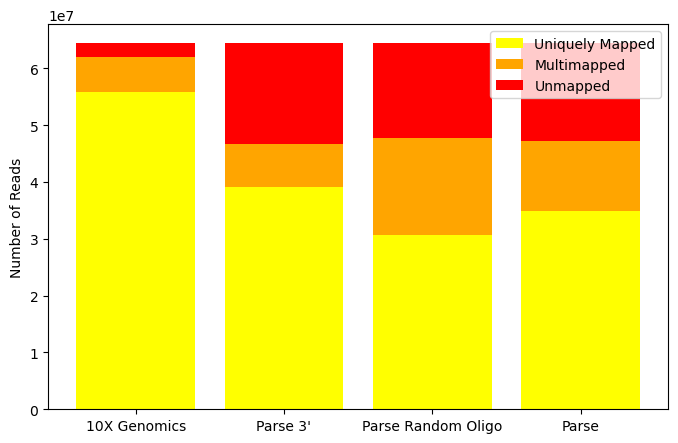

In [16]:
plotting.plot_filtering_metrics_star(datasets)

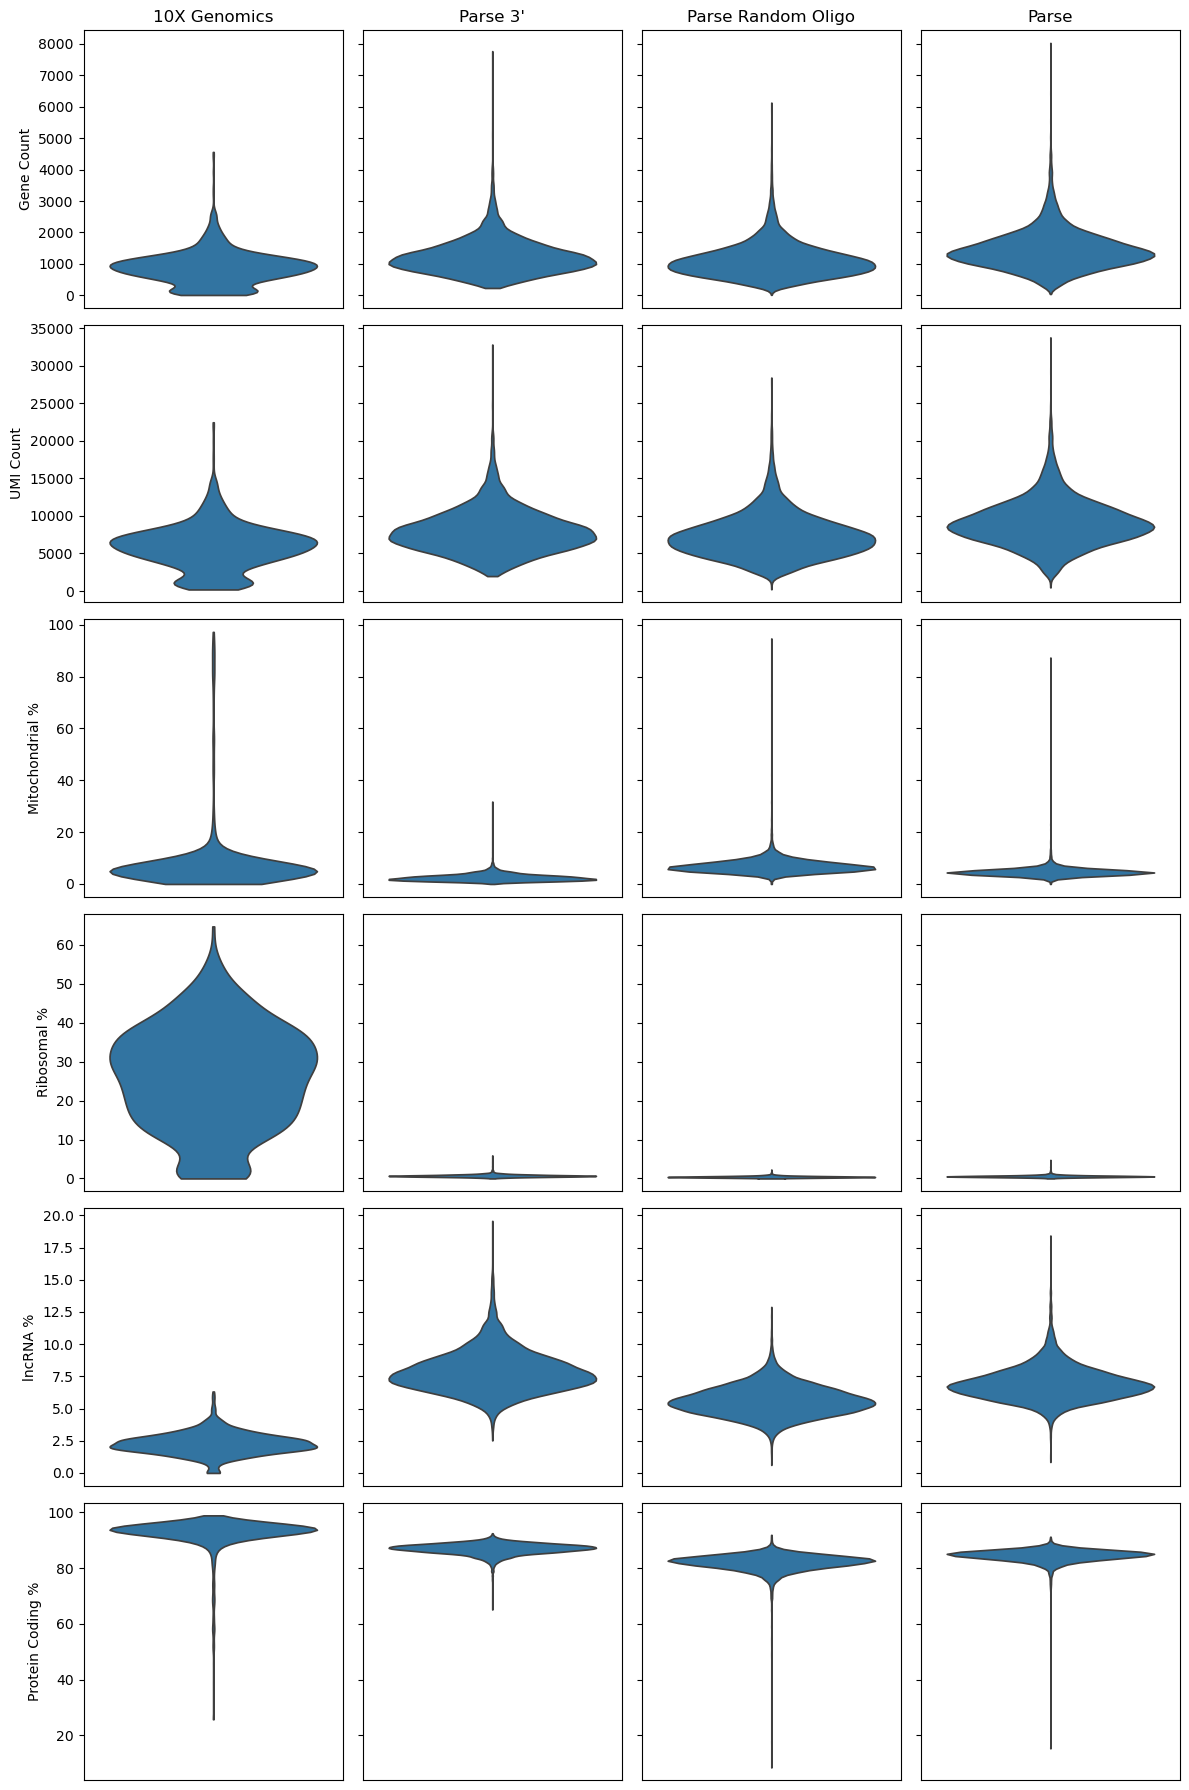

In [ ]:
groups = ['n_genes', 'n_counts', 'percent_nascent', 'percent_mito', 'percent_ribo', 'percent_lnc', 'percent_pc']
group_names = ['Gene Count', 'UMI Count', 'Nascent %', 'Mitochondrial %', 'Ribosomal %', 'lncRNA %', 'Protein Coding %']

plotting.plot_cell_metrics(datasets, groups=groups, group_names=group_names)

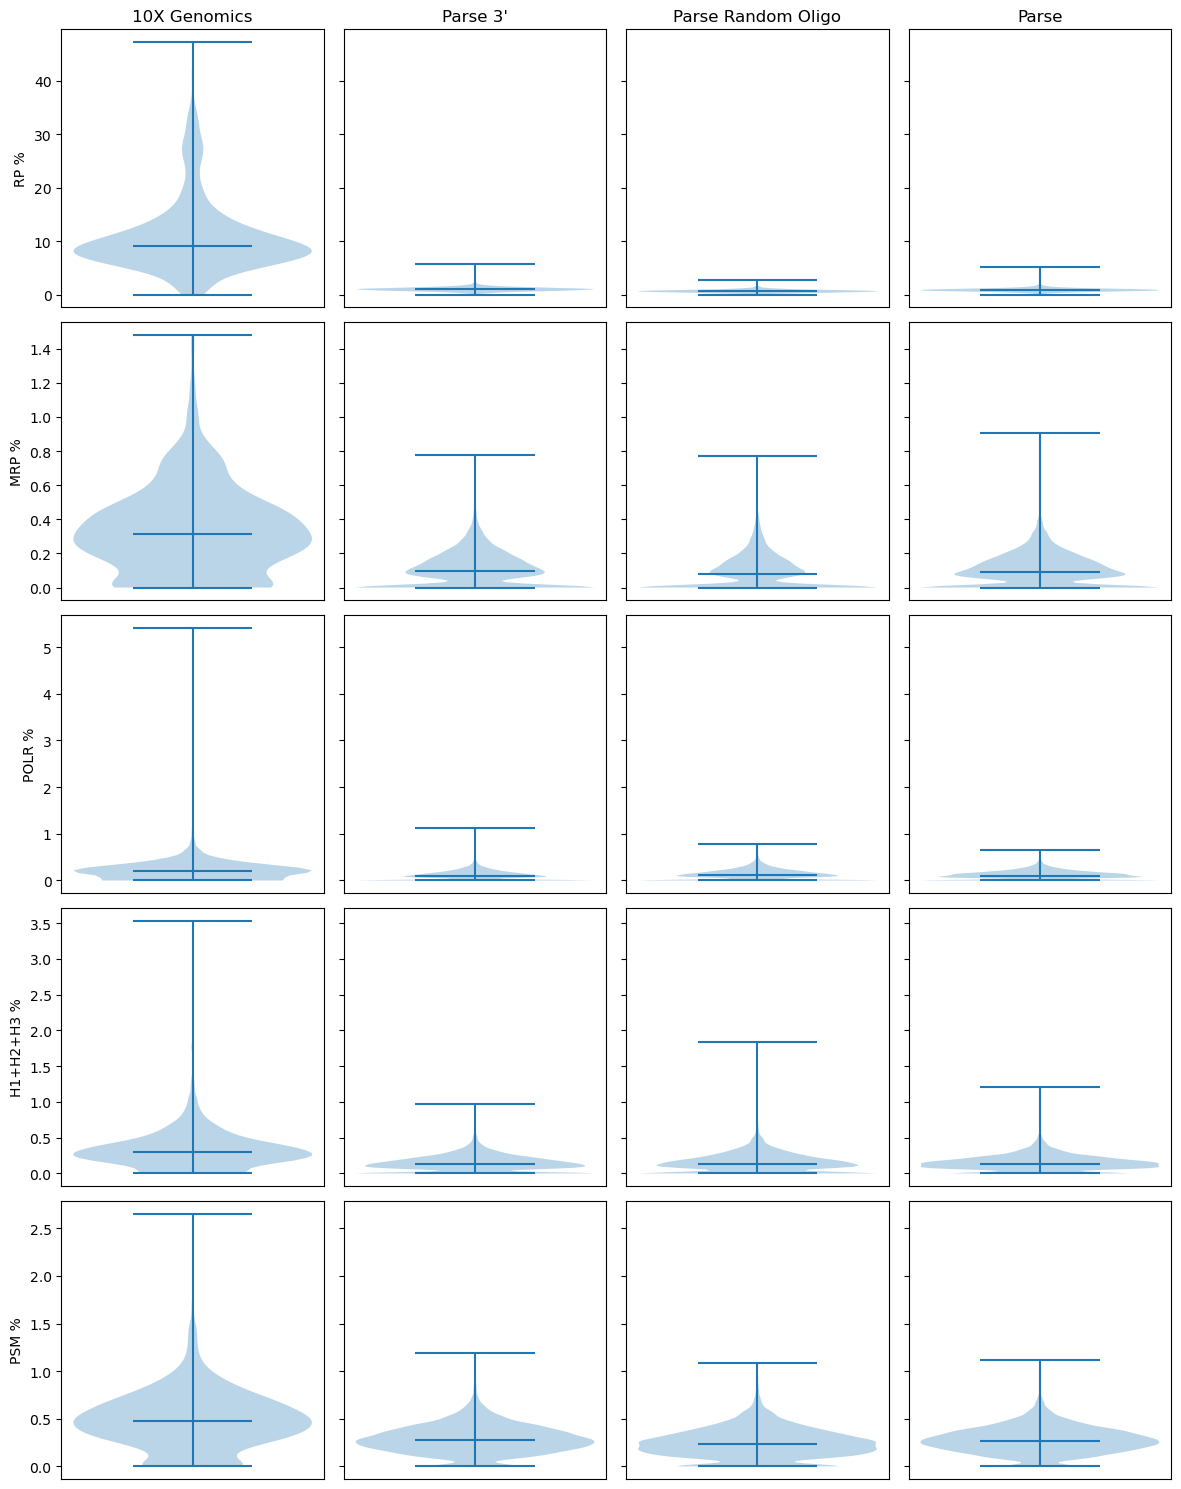

In [18]:
# Transcriptional Gene Family Percentages
plotting.plot_gene_family_percentages(datasets, gene_families=["RP", "MRP", "POLR", "H1+H2+H3", "PSM"])

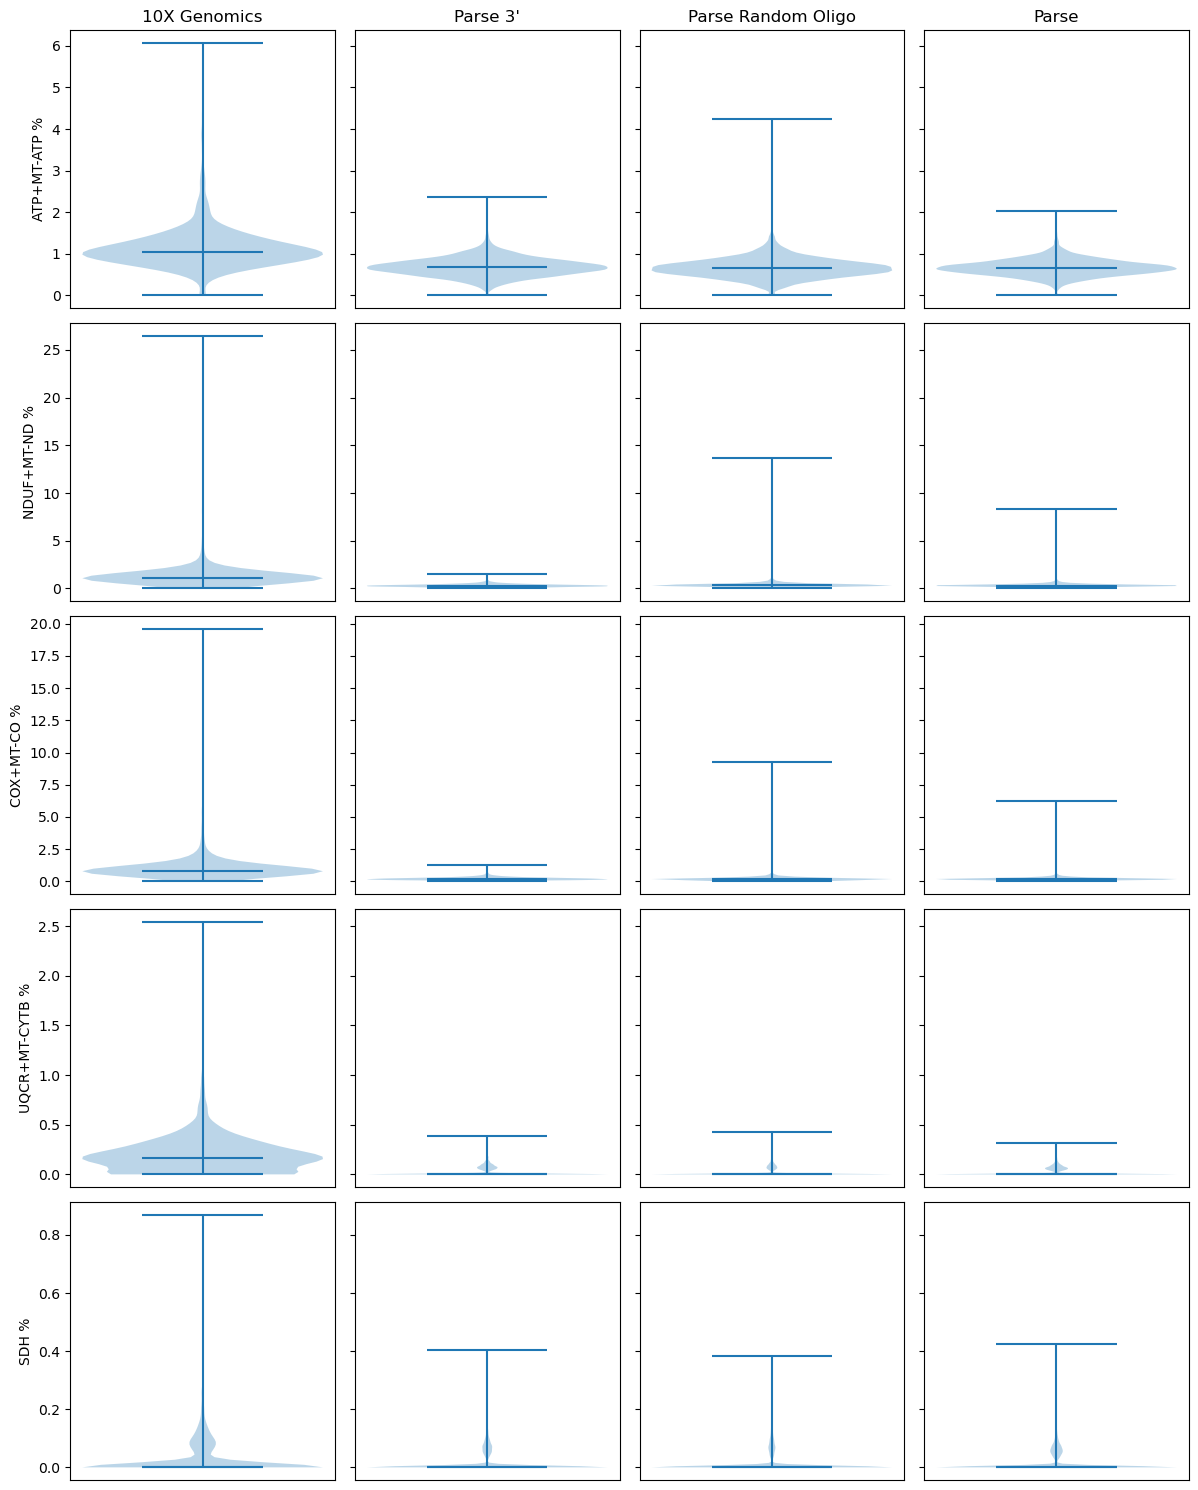

In [19]:
# OXPHOS Gene Family Percentages
plotting.plot_gene_family_percentages(datasets, gene_families=["ATP+MT-ATP", "NDUF+MT-ND", "COX+MT-CO", "UQCR+MT-CYTB", "SDH"])

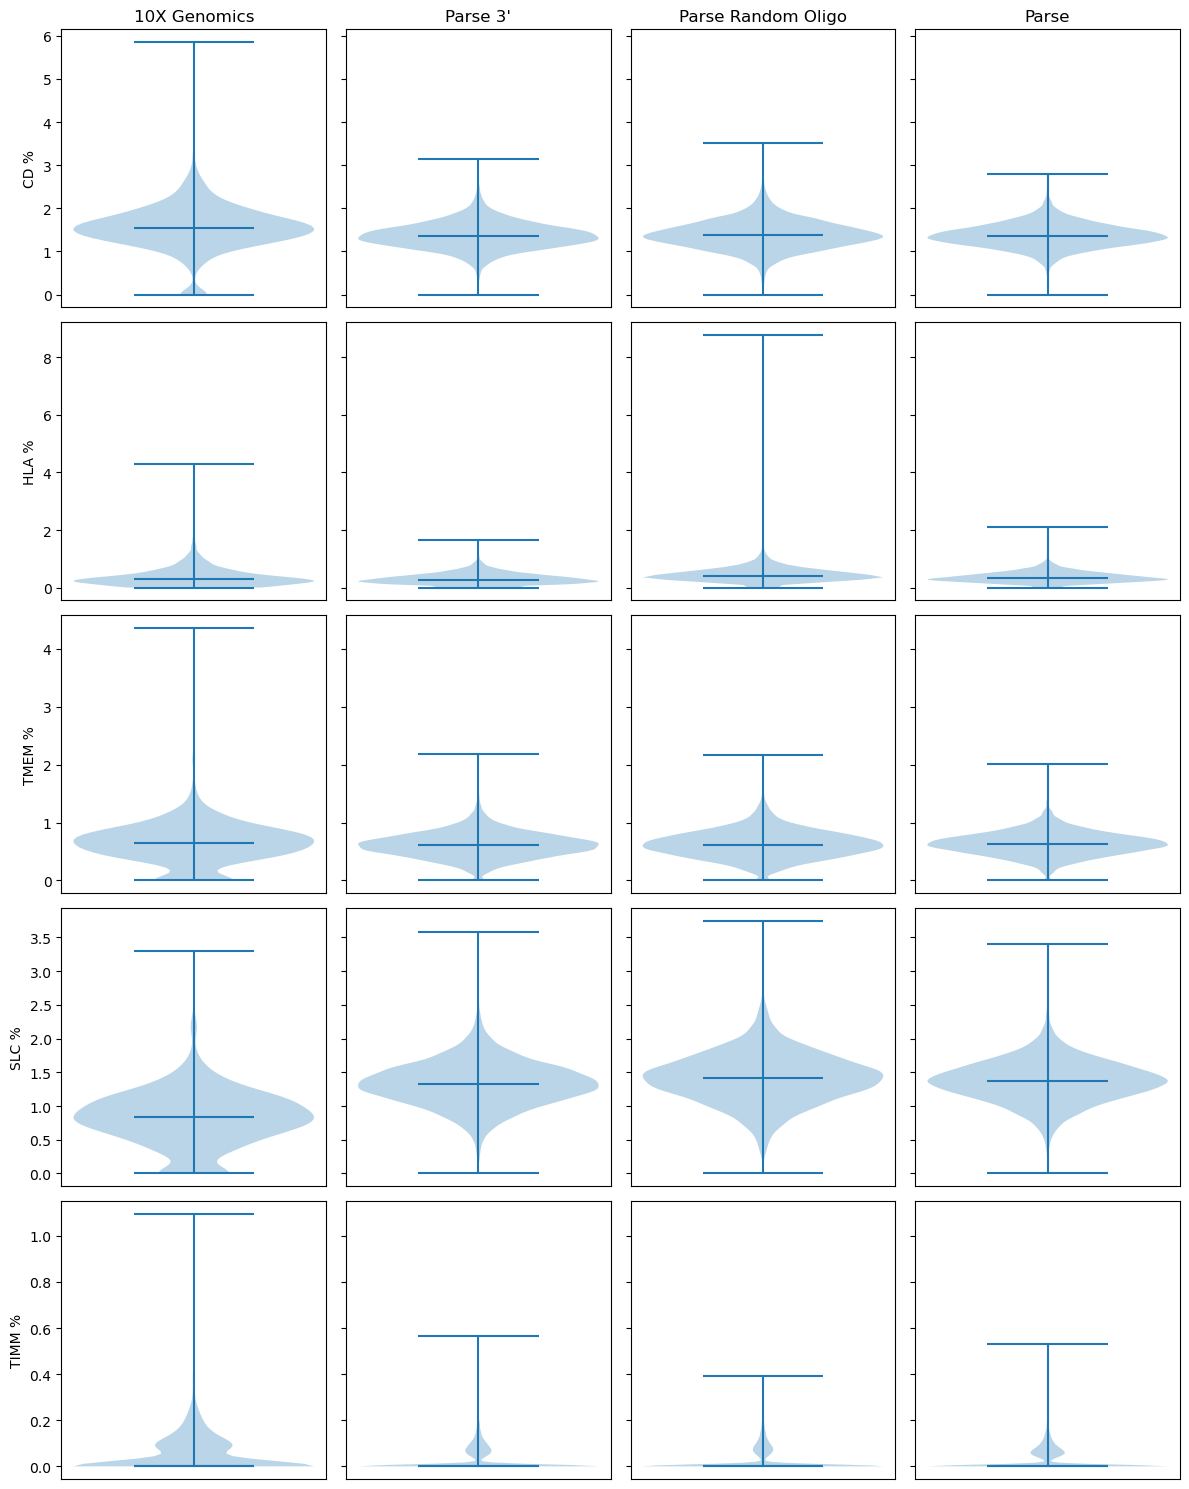

In [20]:
# Cell surface and transmembrane protein gene family percentages
plotting.plot_gene_family_percentages(datasets, gene_families=["CD", "HLA", "TMEM", "SLC", "TIMM"])

# Read/Gene Comparisons

In [22]:
# Marker genes for PBMCs from www.biocompare.com
T_marker_names = ['CD3D', 'CD3G', 'CD3E', 'CD4', 'CD8A', 'CD8B']

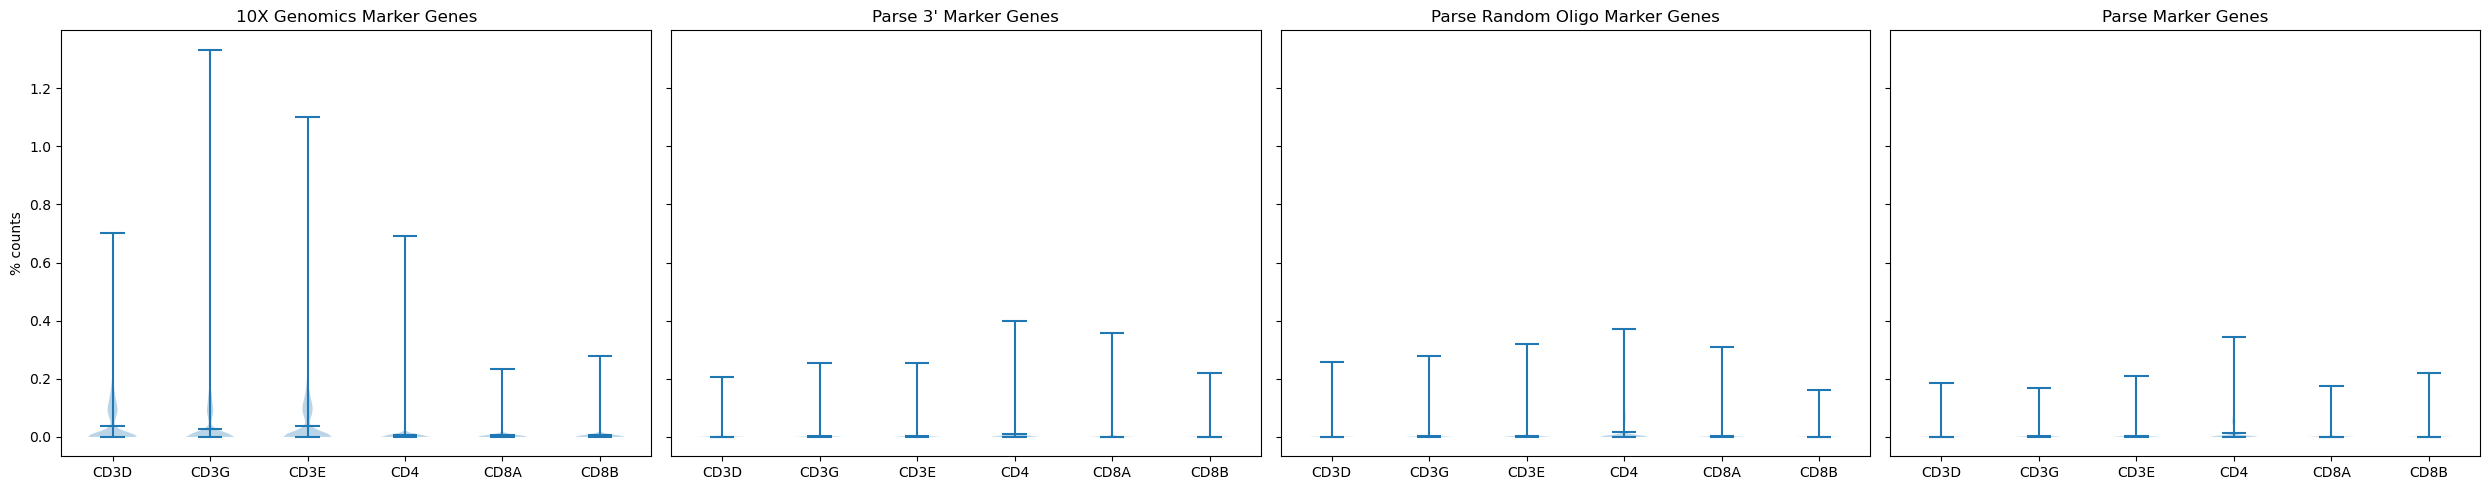

In [23]:
plotting.marker_genes(datasets, T_marker_names)

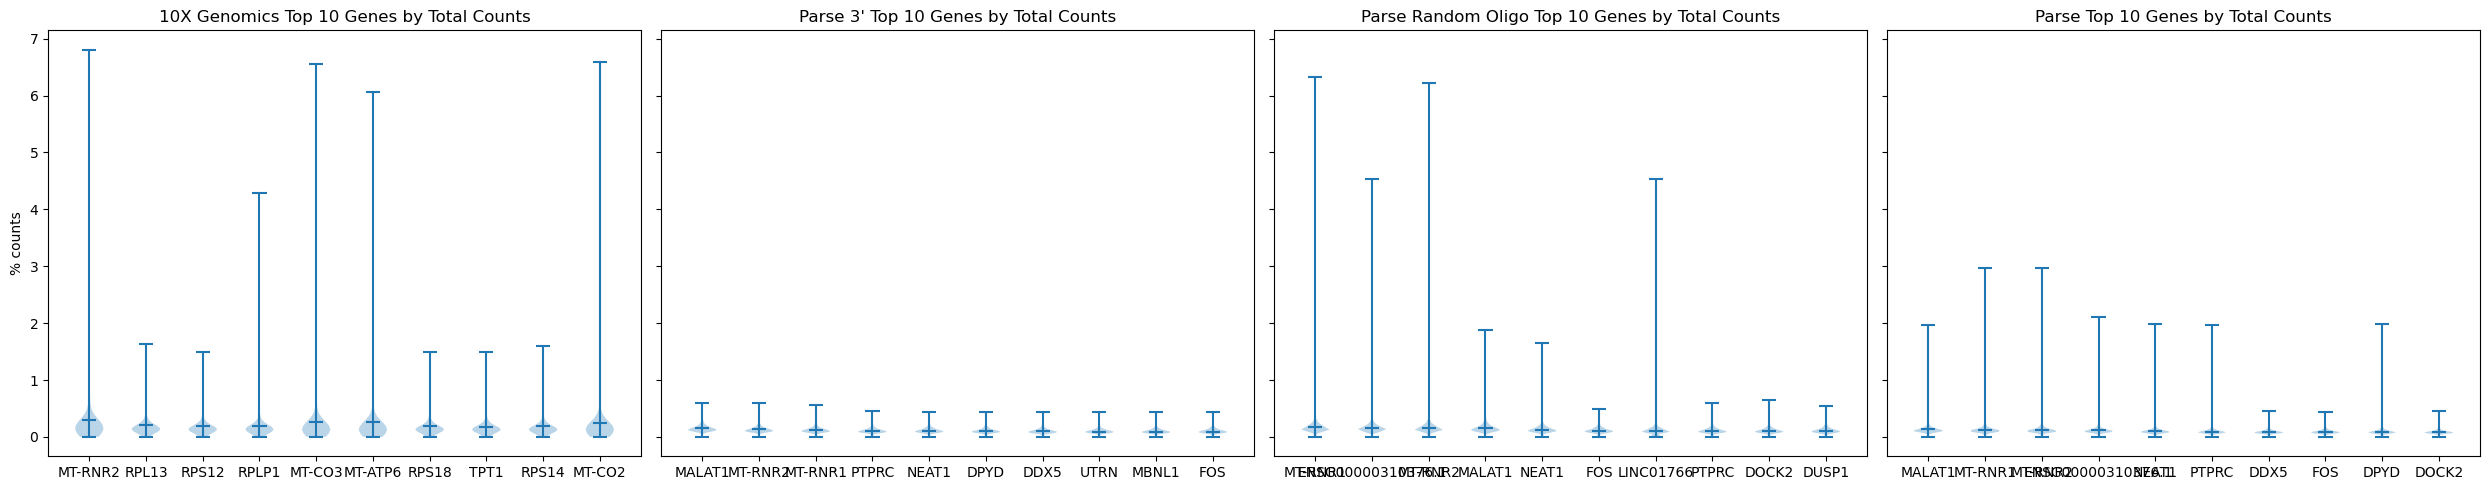

In [24]:
plotting.top_gene_counts(datasets)

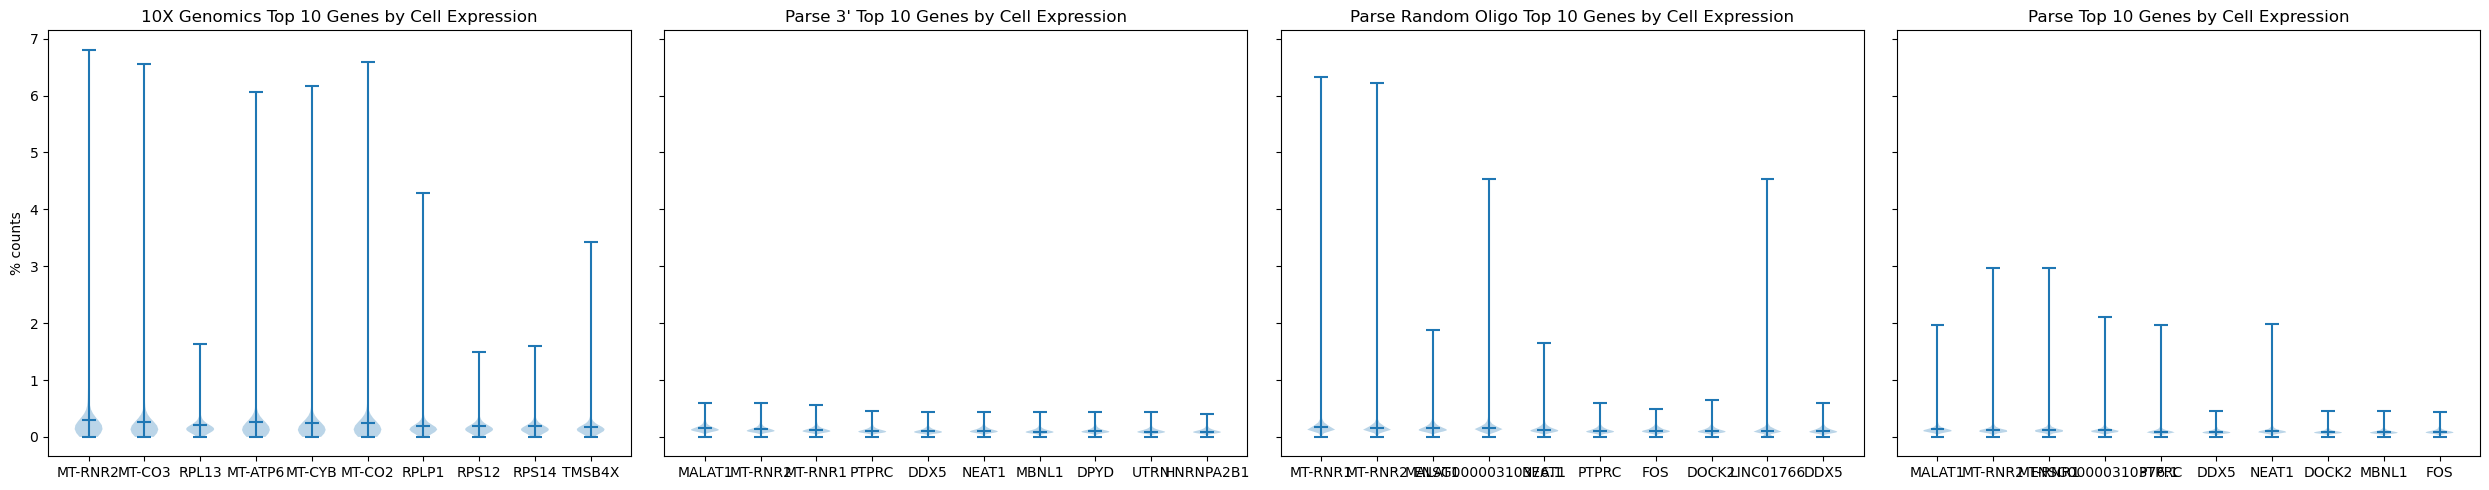

In [25]:
plotting.top_gene_cell_expression(datasets)

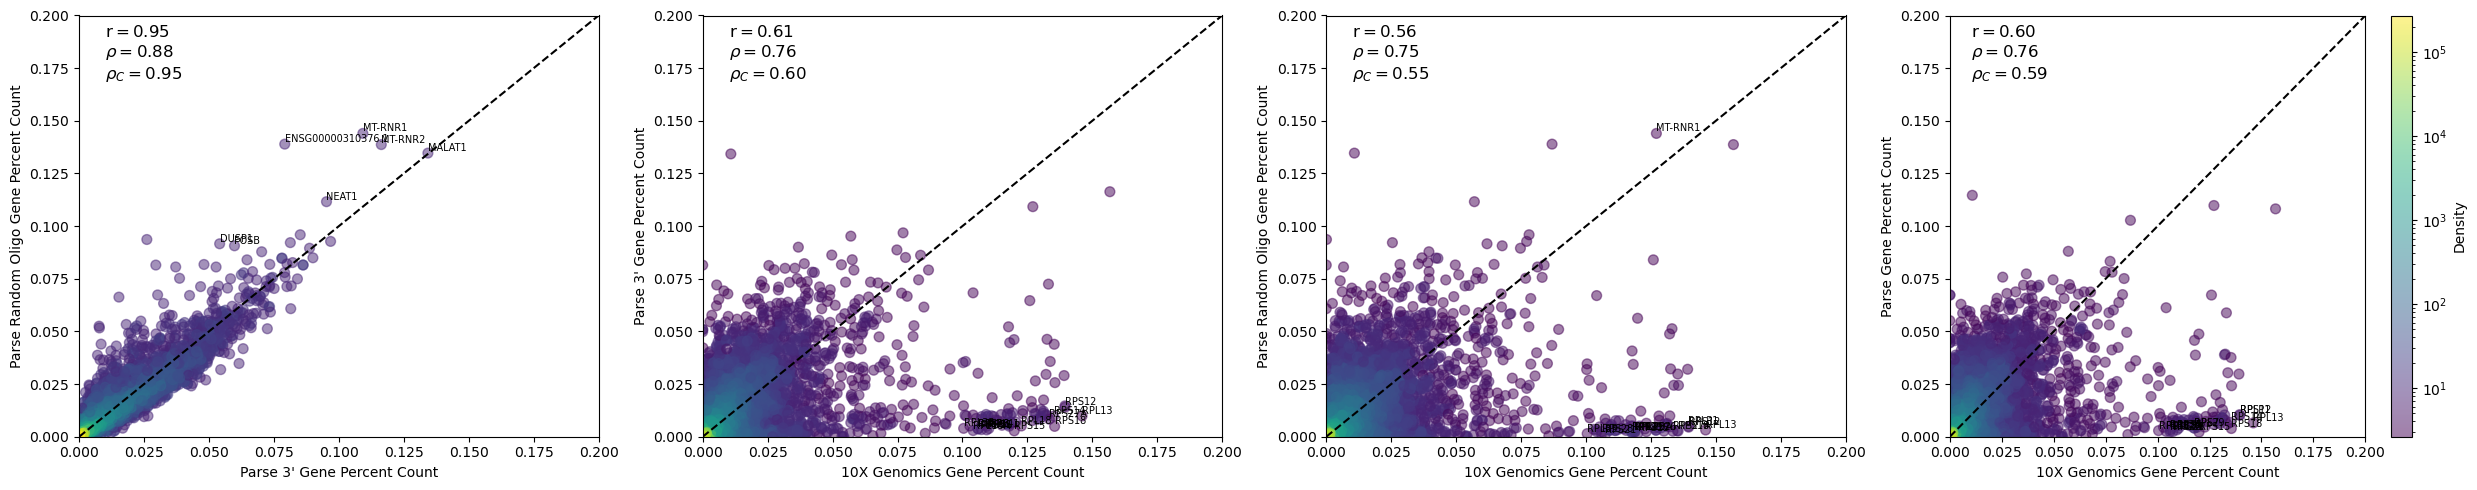

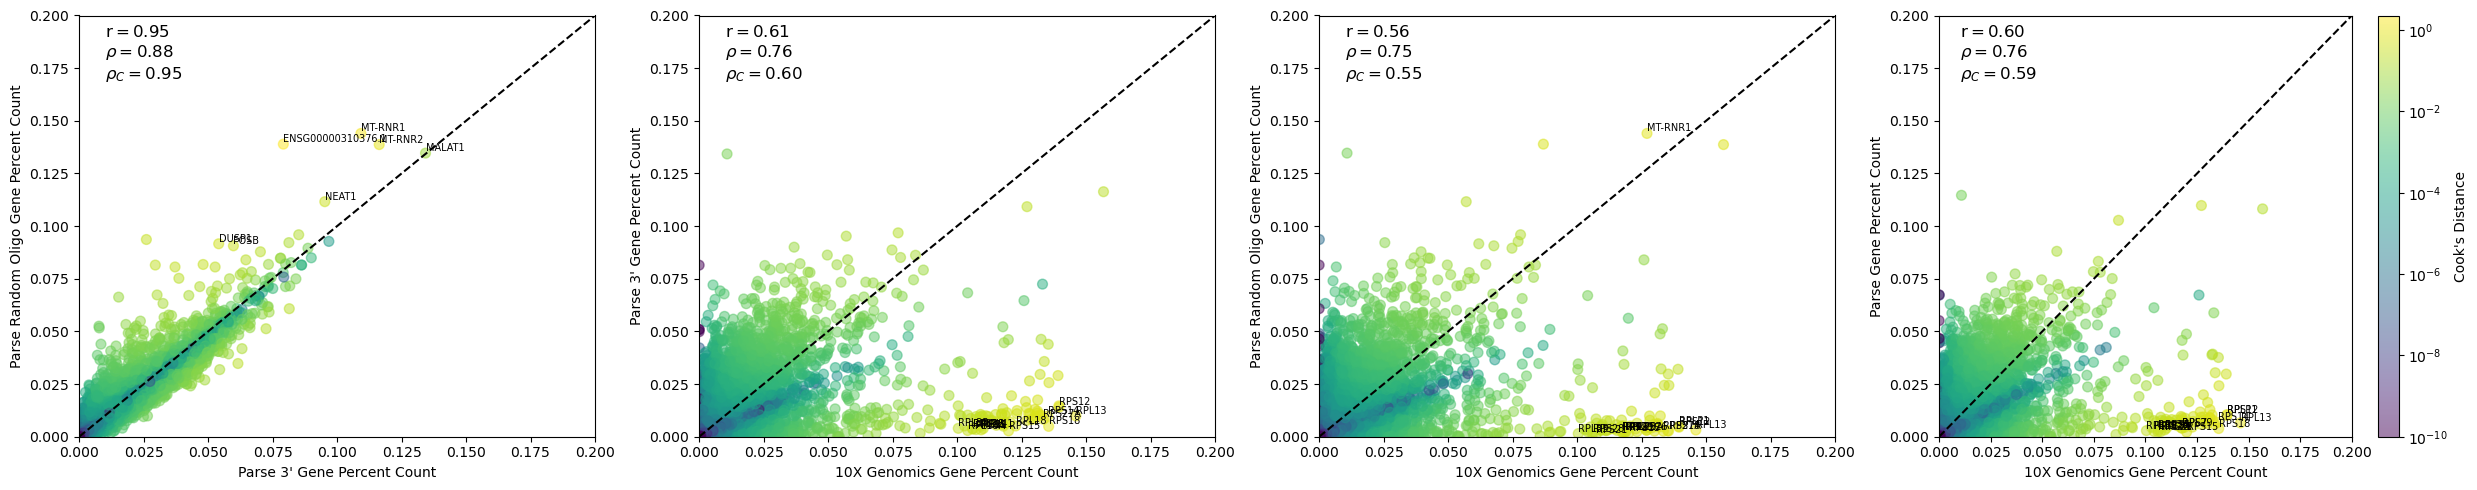

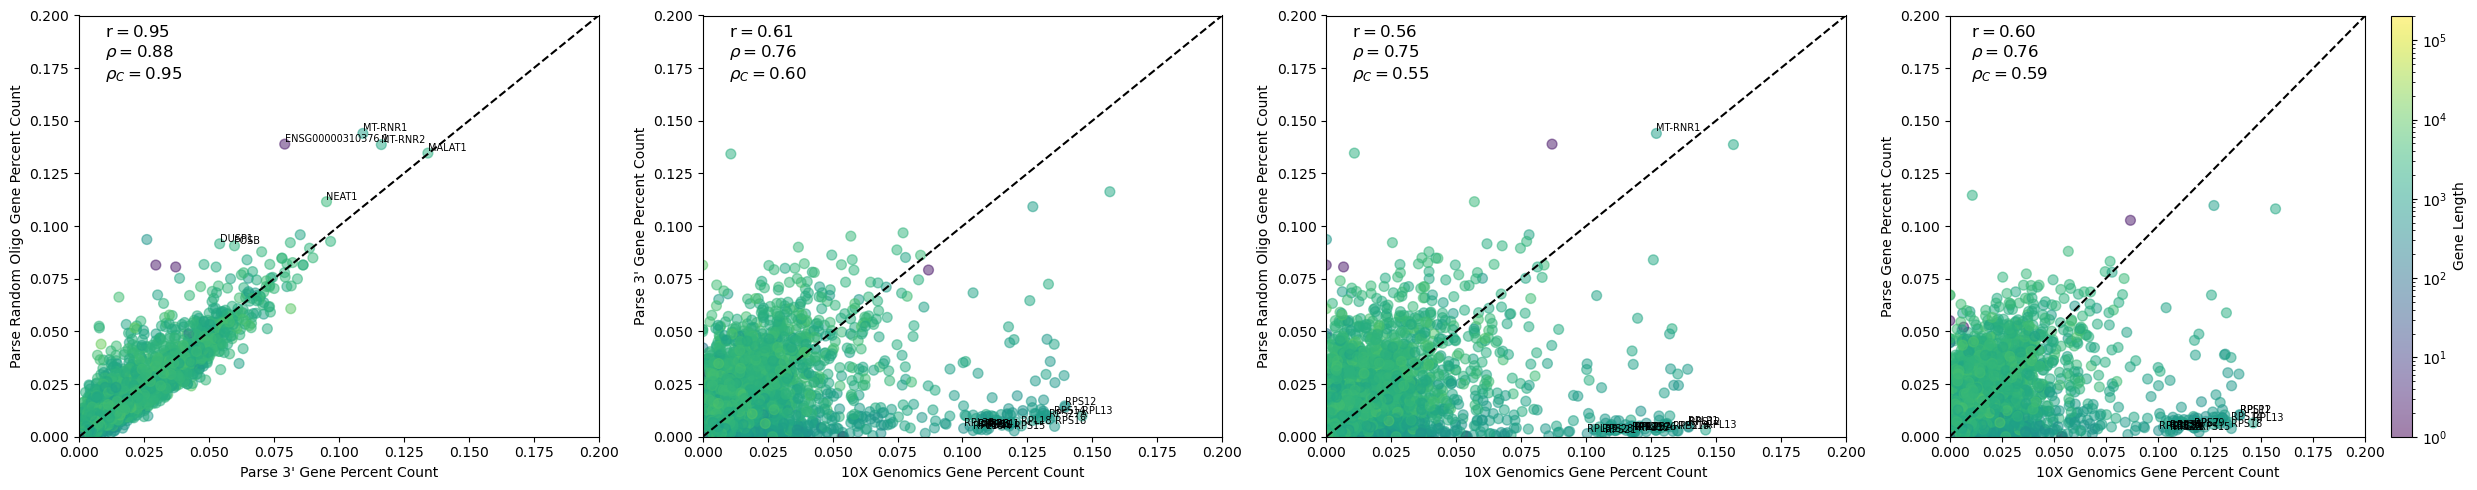

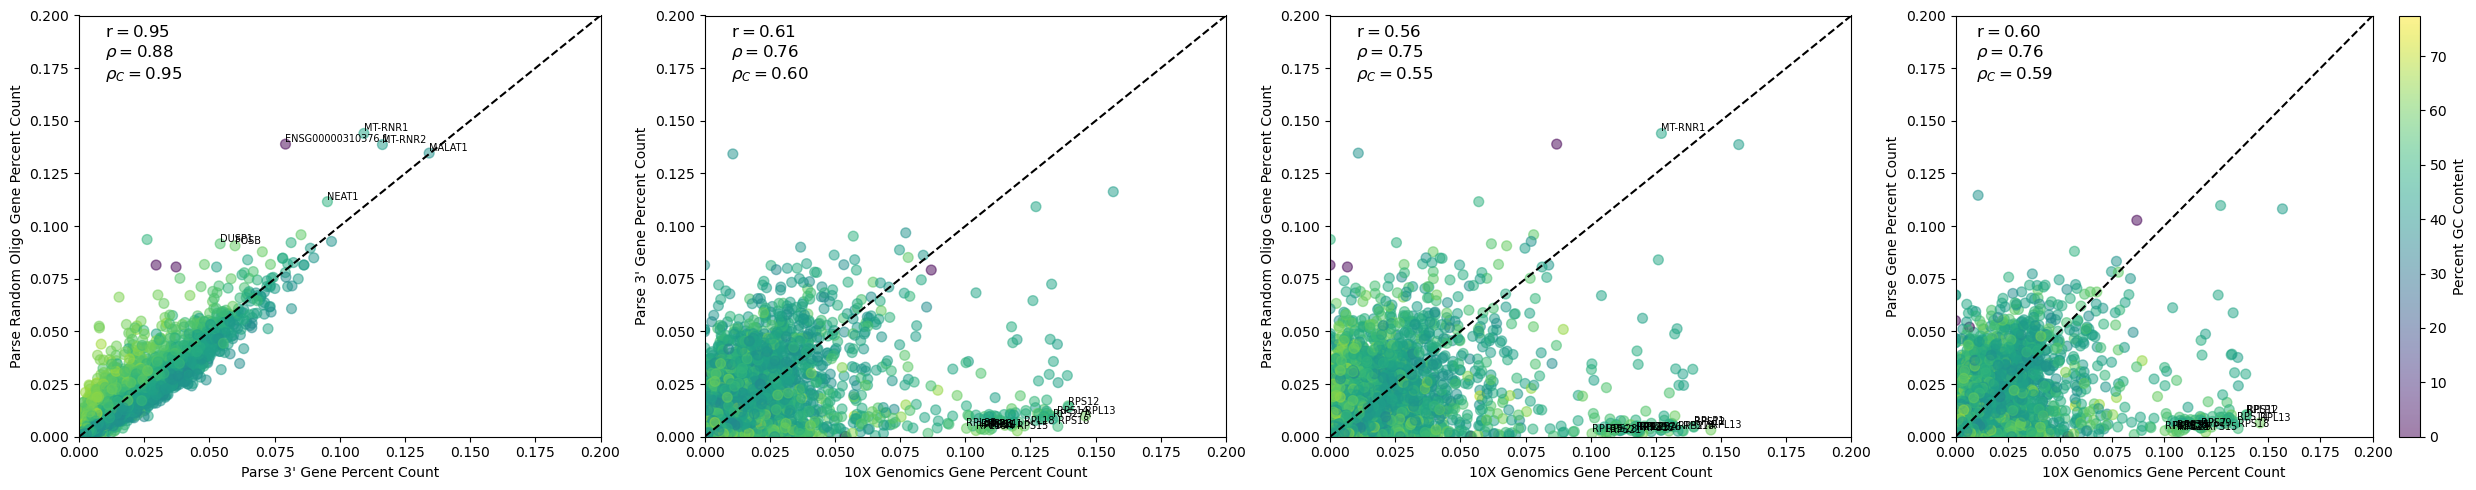

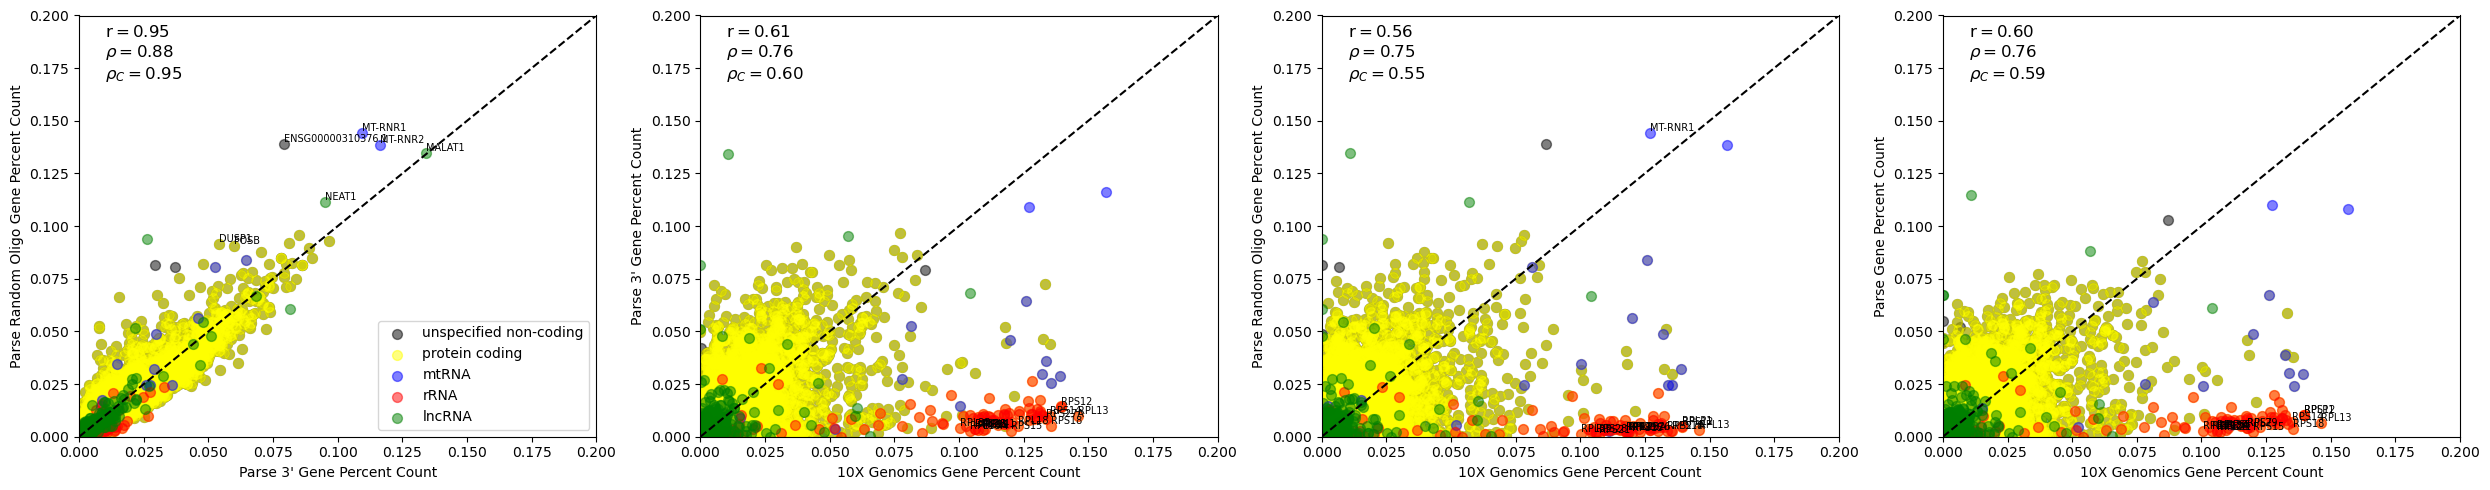

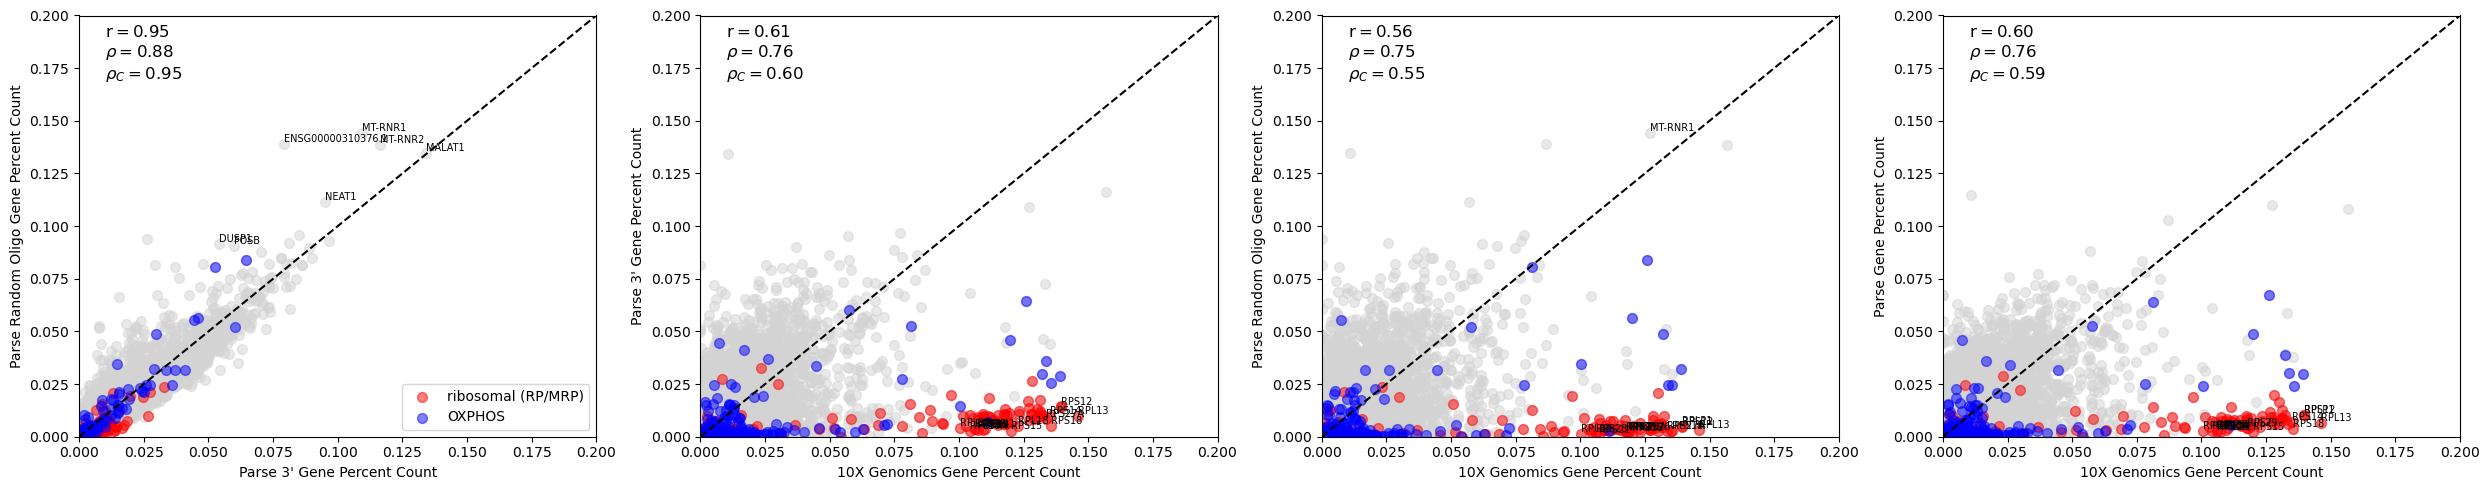

In [26]:
if LOGCPM_TRANSFORM:
    compare_names, compare_dfs = plotting.compare(datasets, 0.2)

In [27]:
if not LOGCPM_TRANSFORM:
    compare_names, compare_dfs = plotting.compare(datasets, 8)

In [28]:
if not LOGCPM_TRANSFORM:
    _, _ = plotting.compare(datasets, 1.5)

In [29]:
if not LOGCPM_TRANSFORM:
    _, _ = plotting.compare(datasets, 0.5)

In [30]:
for name, df in zip(compare_names, compare_dfs):
    gene_info = plotting.merge_by_cooks(gene_info, name, df)
gene_info.to_csv(FULL_GENE_INFO_PATH)